In [1]:
!gdown 10ew0IXa55MqUwBJxUGAeHFVhDS-zwkib

Downloading...
From: https://drive.google.com/uc?id=10ew0IXa55MqUwBJxUGAeHFVhDS-zwkib
To: /content/Salaries.csv
100% 246/246 [00:00<00:00, 75.6kB/s]


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Load Data

In [3]:
df = pd.read_csv('./Salaries.csv')
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [4]:
X = df.Level
X

,Level
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [5]:
y = df.Salary
y

,Salary
0,45000
1,50000
2,60000
3,80000
4,110000
5,150000
6,200000
7,300000
8,500000
9,1000000


Text(0, 0.5, 'Salary')

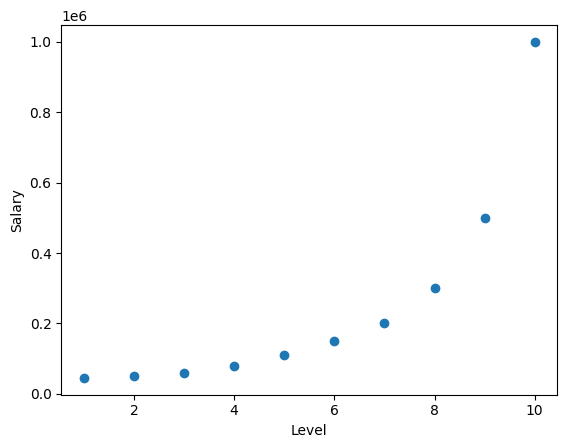

In [6]:
plt.scatter(X, y)
plt.xlabel("Level")
plt.ylabel("Salary")

#Linear Regression

In [7]:
def r2score(y_pred, y):
    rss = np.sum((y_pred - y) ** 2)
    tss = np.sum((y-y.mean()) ** 2)

    r2 = 1 - (rss / tss)
    return r2

In [8]:
class LinearRegression:
    def __init__(self, X_data, y_target, learning_rate=0.01, num_epochs=10000):
        self.X_data = X_data
        self.y_target = y_target
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.num_samples = self.X_data.shape[0]

        # Initial Coefficients
        self.theta = np.random.randn(self.X_data.shape[1])
        self.losses = []

    def compute_loss(self, y_pred, y_target):
        loss = (y_pred-y_target)*(y_pred-y_target)
        loss = np.mean(loss)
        return loss

    def predict(self, X_data):
        y_pred = X_data.dot(self.theta)
        return y_pred

    def fit(self):
        for epoch in range(self.num_epochs):
            # predict
            y_pred = self.predict(self.X_data)

            # compute loss
            loss = self.compute_loss(y_pred, self.y_target)
            self.losses.append(loss)

            # compute gradient
            k = 2*(y_pred-self.y_target)
            gradients = self.X_data.T.dot(k)/self.num_samples

            # update weight
            self.theta = self.theta - self.learning_rate*gradients

            print(f'Epoch: {epoch} - Loss: {loss}')

        return {
            'loss': sum(self.losses)/len(self.losses),
            'weight': self.theta
        }

In [9]:
X_linear = X.values.reshape(-1, 1)
X_linear = np.hstack((np.ones((X_linear.shape[0], 1)), X_linear))

In [10]:
X_linear

array([[ 1.,  1.],
       [ 1.,  2.],
       [ 1.,  3.],
       [ 1.,  4.],
       [ 1.,  5.],
       [ 1.,  6.],
       [ 1.,  7.],
       [ 1.,  8.],
       [ 1.,  9.],
       [ 1., 10.]])

In [11]:
linear_model = LinearRegression(X_linear, y, num_epochs=100)
linear_model.fit()

Epoch: 0 - Loss: 142906082215.4709
Epoch: 1 - Loss: 40360858386.34984
Epoch: 2 - Loss: 35586092279.06973
Epoch: 3 - Loss: 35297761211.34552
Epoch: 4 - Loss: 35215854736.940285
Epoch: 5 - Loss: 35143994936.6167
Epoch: 6 - Loss: 35073166883.63726
Epoch: 7 - Loss: 35002952176.10186
Epoch: 8 - Loss: 34933326873.1692
Epoch: 9 - Loss: 34864285172.20167
Epoch: 10 - Loss: 34795822142.19662
Epoch: 11 - Loss: 34727932931.2407
Epoch: 12 - Loss: 34660612729.81914
Epoch: 13 - Loss: 34593856768.807304
Epoch: 14 - Loss: 34527660319.05641
Epoch: 15 - Loss: 34462018691.05483
Epoch: 16 - Loss: 34396927234.595924
Epoch: 17 - Loss: 34332381338.448402
Epoch: 18 - Loss: 34268376430.029804
Epoch: 19 - Loss: 34204907975.082478
Epoch: 20 - Loss: 34141971477.352417
Epoch: 21 - Loss: 34079562478.270683
Epoch: 22 - Loss: 34017676556.637592
Epoch: 23 - Loss: 33956309328.30949
Epoch: 24 - Loss: 33895456445.888184
Epoch: 25 - Loss: 33835113598.41291
Epoch: 26 - Loss: 33775276511.055035
Epoch: 27 - Loss: 33715940944.

{'loss': 33803407475.782486,
 'weight': array([-62217.56842019,  61757.96607999])}

In [12]:
y_pred = linear_model.predict(X_linear)

In [13]:
r2score(y_pred, y)

0.6219619592474837

In [14]:
linear_model.theta

array([-62217.56842019,  61757.96607999])

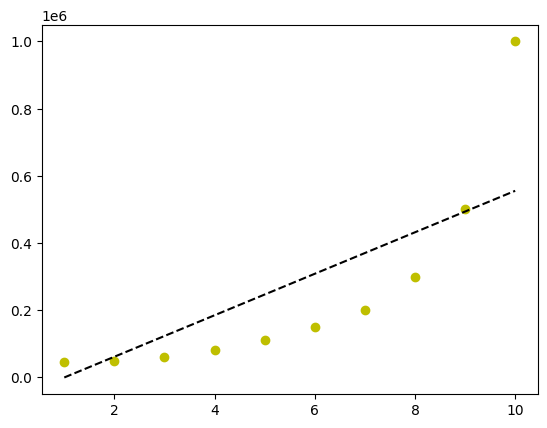

In [15]:
plt.plot(X, y, 'yo', X, linear_model.theta[1]*X + linear_model.theta[0], '--k')
plt.show()

#Polymial Regression

In [16]:
def create_polynomial_features(X, degree=2):
    """Creates the polynomial features
    Args:
        X: A array tensor for the data.
        degree: A intege for the degree of
        the generated polynomial function.
    """
    X_new = X
    for d in range(2, degree+1):
        X_new = np.c_[X_new, np.power(X, d)]
    return X_new

##Polymial Regression with degree = 2

In [17]:
X_poly = create_polynomial_features(X, degree=2)
X_poly

array([[  1,   1],
       [  2,   4],
       [  3,   9],
       [  4,  16],
       [  5,  25],
       [  6,  36],
       [  7,  49],
       [  8,  64],
       [  9,  81],
       [ 10, 100]])

In [18]:
X_poly = np.hstack((np.ones((X_poly.shape[0], 1)), X_poly))
X_poly

array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   4.,  16.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.]])

In [ ]:
poly_model = LinearRegression(X_poly, y, learning_rate=0.0001, num_epochs=10000)
poly_model.fit()

In [20]:
y_pred = poly_model.predict(X_poly)
r2score(y_pred, y)

0.8736077146738805

In [21]:
poly_model.theta

array([ 14600.06335464, -47837.80773032,  12584.31574081])

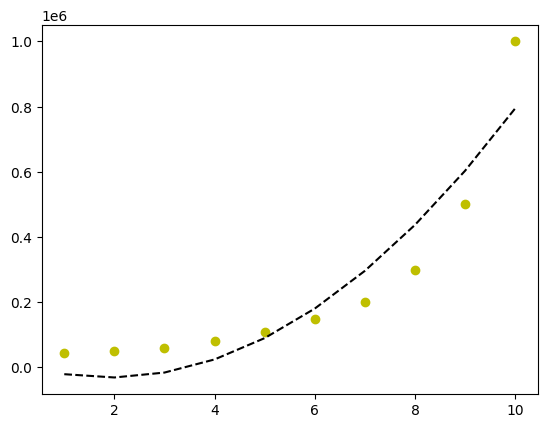

In [22]:
X_plot = df.Level
y_func = poly_model.theta[2]*X*X + poly_model.theta[1]*X + poly_model.theta[0]
plt.plot(X_plot, y, 'yo', X, y_func, '--k')
plt.show()

##Polymial Regression with degree = 3

In [23]:
X_poly = create_polynomial_features(X, degree=3)
X_poly

array([[   1,    1,    1],
       [   2,    4,    8],
       [   3,    9,   27],
       [   4,   16,   64],
       [   5,   25,  125],
       [   6,   36,  216],
       [   7,   49,  343],
       [   8,   64,  512],
       [   9,   81,  729],
       [  10,  100, 1000]])

In [24]:
X_poly = np.hstack((np.ones((X_poly.shape[0], 1)), X_poly))
X_poly

array([[   1.,    1.,    1.,    1.],
       [   1.,    2.,    4.,    8.],
       [   1.,    3.,    9.,   27.],
       [   1.,    4.,   16.,   64.],
       [   1.,    5.,   25.,  125.],
       [   1.,    6.,   36.,  216.],
       [   1.,    7.,   49.,  343.],
       [   1.,    8.,   64.,  512.],
       [   1.,    9.,   81.,  729.],
       [   1.,   10.,  100., 1000.]])

In [33]:
poly_model = LinearRegression(X_poly, y, learning_rate=0.000001, num_epochs=500)
poly_model.fit()

Epoch: 0 - Loss: 143466666740.03174
Epoch: 1 - Loss: 56030328690.59806
Epoch: 2 - Loss: 24624062513.82373
Epoch: 3 - Loss: 13343048557.493946
Epoch: 4 - Loss: 9290756010.268642
Epoch: 5 - Loss: 7834923560.728557
Epoch: 6 - Loss: 7311704925.606746
Epoch: 7 - Loss: 7123468782.250104
Epoch: 8 - Loss: 7055553955.864027
Epoch: 9 - Loss: 7030857024.610498
Epoch: 10 - Loss: 7021683470.985904
Epoch: 11 - Loss: 7018085794.830668
Epoch: 12 - Loss: 7016490987.159494
Epoch: 13 - Loss: 7015615670.925924
Epoch: 14 - Loss: 7014998874.240639
Epoch: 15 - Loss: 7014475022.142923
Epoch: 16 - Loss: 7013984642.296427
Epoch: 17 - Loss: 7013506373.007815
Epoch: 18 - Loss: 7013032541.416783
Epoch: 19 - Loss: 7012560391.508753
Epoch: 20 - Loss: 7012088933.334305
Epoch: 21 - Loss: 7011617811.291036
Epoch: 22 - Loss: 7011146897.625481
Epoch: 23 - Loss: 7010676146.424498
Epoch: 24 - Loss: 7010205541.170883
Epoch: 25 - Loss: 7009735075.906084
Epoch: 26 - Loss: 7009264748.464064
Epoch: 27 - Loss: 7008794558.041037


{'loss': 7334682154.742986,
 'weight': array([   0.90488824,  -47.5690296 , -233.7379258 ,  855.48492612])}

In [34]:
y_pred = poly_model.predict(X_poly)
r2score(y_pred, y)

0.915685260611815

In [35]:
poly_model.theta

array([   0.90488824,  -47.5690296 , -233.7379258 ,  855.48492612])

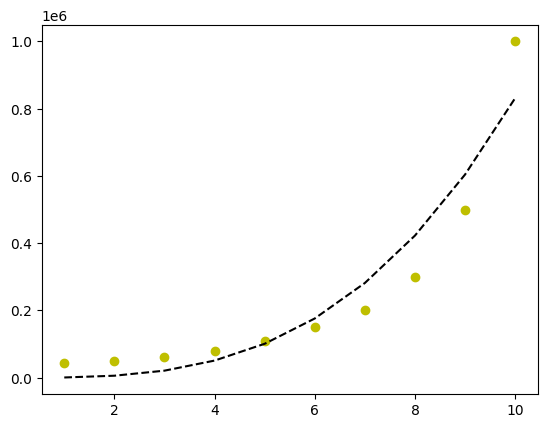

In [36]:
X_plot = df.Level
y_func = poly_model.theta[3]*X*X*X + poly_model.theta[2]*X*X + poly_model.theta[1]*X + poly_model.theta[0]
plt.plot(X_plot, y, 'yo', X, y_func, '--k')
plt.show()

## **Sklearn**

In [37]:
from sklearn.preprocessing import PolynomialFeatures

In [38]:
poly_features = PolynomialFeatures(degree=2)

In [51]:
X.to_frame()

(10, 1)

In [52]:
X_poly = poly_features.fit_transform(X.to_frame())
X_poly

array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   4.,  16.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.]])

In [53]:
poly_model = LinearRegression(X_poly, y, learning_rate=0.000001, num_epochs=500)
poly_model.fit()

Epoch: 0 - Loss: 142952736969.93948
Epoch: 1 - Loss: 141646902853.3964
Epoch: 2 - Loss: 140354457936.71786
Epoch: 3 - Loss: 139075264930.3668
Epoch: 4 - Loss: 137809187952.53882
Epoch: 5 - Loss: 136556092514.72807
Epoch: 6 - Loss: 135315845507.4406
Epoch: 7 - Loss: 134088315186.05417
Epoch: 8 - Loss: 132873371156.8234
Epoch: 9 - Loss: 131670884363.02798
Epoch: 10 - Loss: 130480727071.2634
Epoch: 11 - Loss: 129302772857.87186
Epoch: 12 - Loss: 128136896595.51236
Epoch: 13 - Loss: 126982974439.86887
Epoch: 14 - Loss: 125840883816.49414
Epoch: 15 - Loss: 124710503407.78911
Epoch: 16 - Loss: 123591713140.11531
Epoch: 17 - Loss: 122484394171.0397
Epoch: 18 - Loss: 121388428876.71
Epoch: 19 - Loss: 120303700839.36002
Epoch: 20 - Loss: 119230094834.94234
Epoch: 21 - Loss: 118167496820.88852
Epoch: 22 - Loss: 117115793923.99443
Epoch: 23 - Loss: 116074874428.42973
Epoch: 24 - Loss: 115044627763.87068
Epoch: 25 - Loss: 114024944493.75415
Epoch: 26 - Loss: 113015716303.65259
Epoch: 27 - Loss: 11

{'loss': 40289055413.98494,
 'weight': array([  74.99824193,  665.31700709, 6469.3104289 ])}

In [54]:
y_pred = poly_model.predict(X_poly)
r2score(y_pred, y)

0.7977071142549389

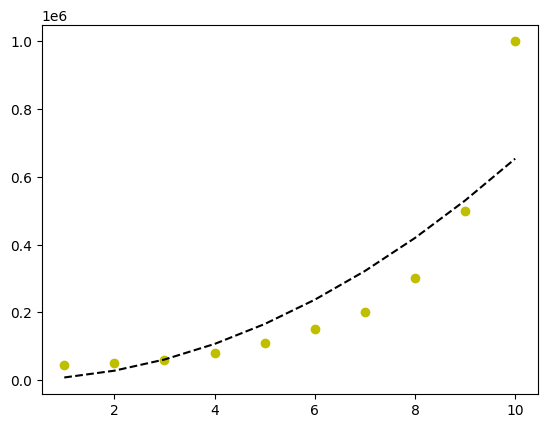

In [55]:
X_plot = df.Level
y_func = poly_model.theta[2]*X*X + poly_model.theta[1]*X + poly_model.theta[0]
plt.plot(X_plot, y, 'yo', X, y_func, '--k')
plt.show()

# **Curve Fit from Scipy**

In [56]:
from scipy import optimize

In [57]:
def func(x, a, b):
    y = a*np.exp(b*x)
    return y

In [58]:
X

,Level
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [60]:
y

,Salary
0,45000
1,50000
2,60000
3,80000
4,110000
5,150000
6,200000
7,300000
8,500000
9,1000000


In [61]:
alpha, beta = optimize.curve_fit(func, xdata = X, ydata = y)[0]
print(f'alpha={alpha}, beta={beta}')

alpha=4589.3907482016875, beta=0.5346899470728618


In [62]:
y_pred = func(X, alpha, beta)

In [63]:
r2score(y_pred, y)

0.9808034598161862

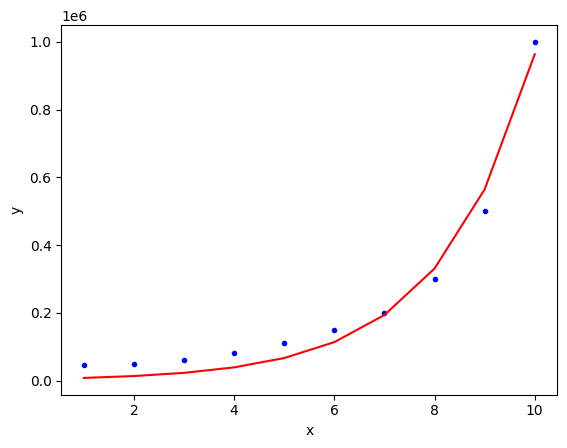

In [68]:
plt.plot(X, y, 'b.')
plt.plot(X, alpha*np.exp(beta*X), 'r')
plt.xlabel('x')
plt.ylabel('y')
plt.show()